# Phase 7 — U-Net Segmentation & CDR Computation

**Goal:** Train two U-Nets on DRISHTI-GS1 to segment the optic disc and cup,
then compute accurate CDR for all classification datasets.

Pipeline:
1. Train `disc_unet` on DRISHTI OD softmaps
2. Train `cup_unet` on DRISHTI cup softmaps  
3. Run inference on ACRIMA + RIMONE + AIROGS test images
4. Compute CDR per image → `cdr_unet` column
5. Compare U-Net CDR vs proxy CDR vs DRISHTI ground truth

**Note:** DRISHTI has only 50 training images — aggressive augmentation is used.
Target Dice: disc >0.85, cup >0.75


In [1]:
import sys
from pathlib import Path

def _find_project_root(start, marker='config.py'):
    for parent in [start, *start.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f'Cannot find project root from {start}')

PROJECT_ROOT = _find_project_root(Path().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print(f'Project root: {PROJECT_ROOT}')

Project root: D:\Machine Learning\glaucoma detection project


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import cv2
import joblib
from tqdm import tqdm
from scipy.stats import pearsonr, spearmanr
from torchvision import transforms

from config import (
    DEVICE, SEG_IMAGE_SIZE, FIGURES_DIR, RESULTS_DIR, MODELS_DIR,
    NORMALIZE_MEAN, NORMALIZE_STD, CDR_GLAUCOMA_THRESHOLD, SEED
)
from data.dataset_loader   import load_drishti_segmentation, load_all_datasets
from models.unet           import build_unet, compute_cdr_from_masks, predict_mask
from models.seg_trainer    import SegDataset, SegTrainer, build_seg_dataloaders

plt.rcParams['figure.dpi'] = 120
print(f'Device: {DEVICE}')

Device: cuda


## 7.1 Load DRISHTI segmentation data

In [3]:
drishti_df = load_drishti_segmentation()
valid_df   = drishti_df.dropna(subset=['od_mask_path', 'cup_mask_path']).reset_index(drop=True)
print(f'Valid samples for training: {len(valid_df)}')

[DRISHTI] Train images : 50
          With OD mask : 50
          With cup mask: 50
          With CDR     : 50  (mean CDR = 0.704)
          Fully valid  : 50
  Note: test split has no public GT — train-only for segmentation.
Valid samples for training: 50


## 7.2 Train disc U-Net
Optic disc is the larger, easier target. Target Dice > 0.85.

In [4]:
disc_train_loader, disc_val_loader = build_seg_dataloaders(
    valid_df, target='disc', val_frac=0.2, batch_size=4
)

disc_model   = build_unet(encoder='resnet18', pretrained=True)
disc_trainer = SegTrainer(disc_model, run_name='disc_unet')

disc_history = disc_trainer.fit(
    disc_train_loader, disc_val_loader,
    epochs=50, lr=1e-3, patience=12
)

[DISC seg]  Train: 40  Val: 10
U-Net (resnet18) | 14,328,209 params | 14,328,209 trainable | device=cuda
SegTrainer: disc_unet  →  checkpoint: D:\Machine Learning\glaucoma detection project\outputs\models\disc_unet_best.pth

═══════════════════════════════════════════════════════
  Training disc_unet  |  max 50 epochs  |  patience 12
═══════════════════════════════════════════════════════
  Epoch   1/50 | Loss 0.6327/1.1418 | Dice 0.4699/0.1202 | IoU 0.0639 | 4.4s
  ✓ Saved  (val Dice 0.1202)
  Epoch   2/50 | Loss 0.4162/1.2524 | Dice 0.7875/0.2031 | IoU 0.1132 | 4.0s
  ✓ Saved  (val Dice 0.2031)
  Epoch   3/50 | Loss 0.2927/0.3364 | Dice 0.8667/0.7609 | IoU 0.6241 | 4.1s
  ✓ Saved  (val Dice 0.7609)
  Epoch   4/50 | Loss 0.2238/0.1981 | Dice 0.8571/0.8928 | IoU 0.8064 | 4.3s
  ✓ Saved  (val Dice 0.8928)
  Epoch   5/50 | Loss 0.1666/0.1418 | Dice 0.8715/0.8929 | IoU 0.8068 | 4.3s
  ✓ Saved  (val Dice 0.8929)
  Epoch   6/50 | Loss 0.1125/0.1204 | Dice 0.9163/0.8950 | IoU 0.8118 | 4.2s
 

## 7.3 Train cup U-Net
Cup is smaller and harder. Target Dice > 0.75.

In [5]:
cup_train_loader, cup_val_loader = build_seg_dataloaders(
    valid_df, target='cup', val_frac=0.2, batch_size=4
)

cup_model   = build_unet(encoder='resnet18', pretrained=True)
cup_trainer = SegTrainer(cup_model, run_name='cup_unet')

cup_history = cup_trainer.fit(
    cup_train_loader, cup_val_loader,
    epochs=50, lr=1e-3, patience=12
)

[CUP seg]  Train: 40  Val: 10
U-Net (resnet18) | 14,328,209 params | 14,328,209 trainable | device=cuda
SegTrainer: cup_unet  →  checkpoint: D:\Machine Learning\glaucoma detection project\outputs\models\cup_unet_best.pth

═══════════════════════════════════════════════════════
  Training cup_unet  |  max 50 epochs  |  patience 12
═══════════════════════════════════════════════════════
  Epoch   1/50 | Loss 0.7024/1.6029 | Dice 0.2702/0.0636 | IoU 0.0329 | 4.2s
  ✓ Saved  (val Dice 0.0636)
  Epoch   2/50 | Loss 0.5267/0.5261 | Dice 0.6226/0.4845 | IoU 0.3468 | 4.1s
  ✓ Saved  (val Dice 0.4845)
  Epoch   3/50 | Loss 0.4360/0.8783 | Dice 0.7134/0.3312 | IoU 0.1998 | 4.3s
  Epoch   4/50 | Loss 0.3767/0.3383 | Dice 0.6729/0.7064 | IoU 0.5501 | 4.4s
  ✓ Saved  (val Dice 0.7064)
  Epoch   5/50 | Loss 0.2886/0.2678 | Dice 0.7577/0.7099 | IoU 0.5512 | 4.2s
  ✓ Saved  (val Dice 0.7099)
  Epoch   6/50 | Loss 0.2363/0.1684 | Dice 0.7640/0.8354 | IoU 0.7183 | 4.1s
  ✓ Saved  (val Dice 0.8354)
  Epo

## 7.4 Training curves — disc and cup

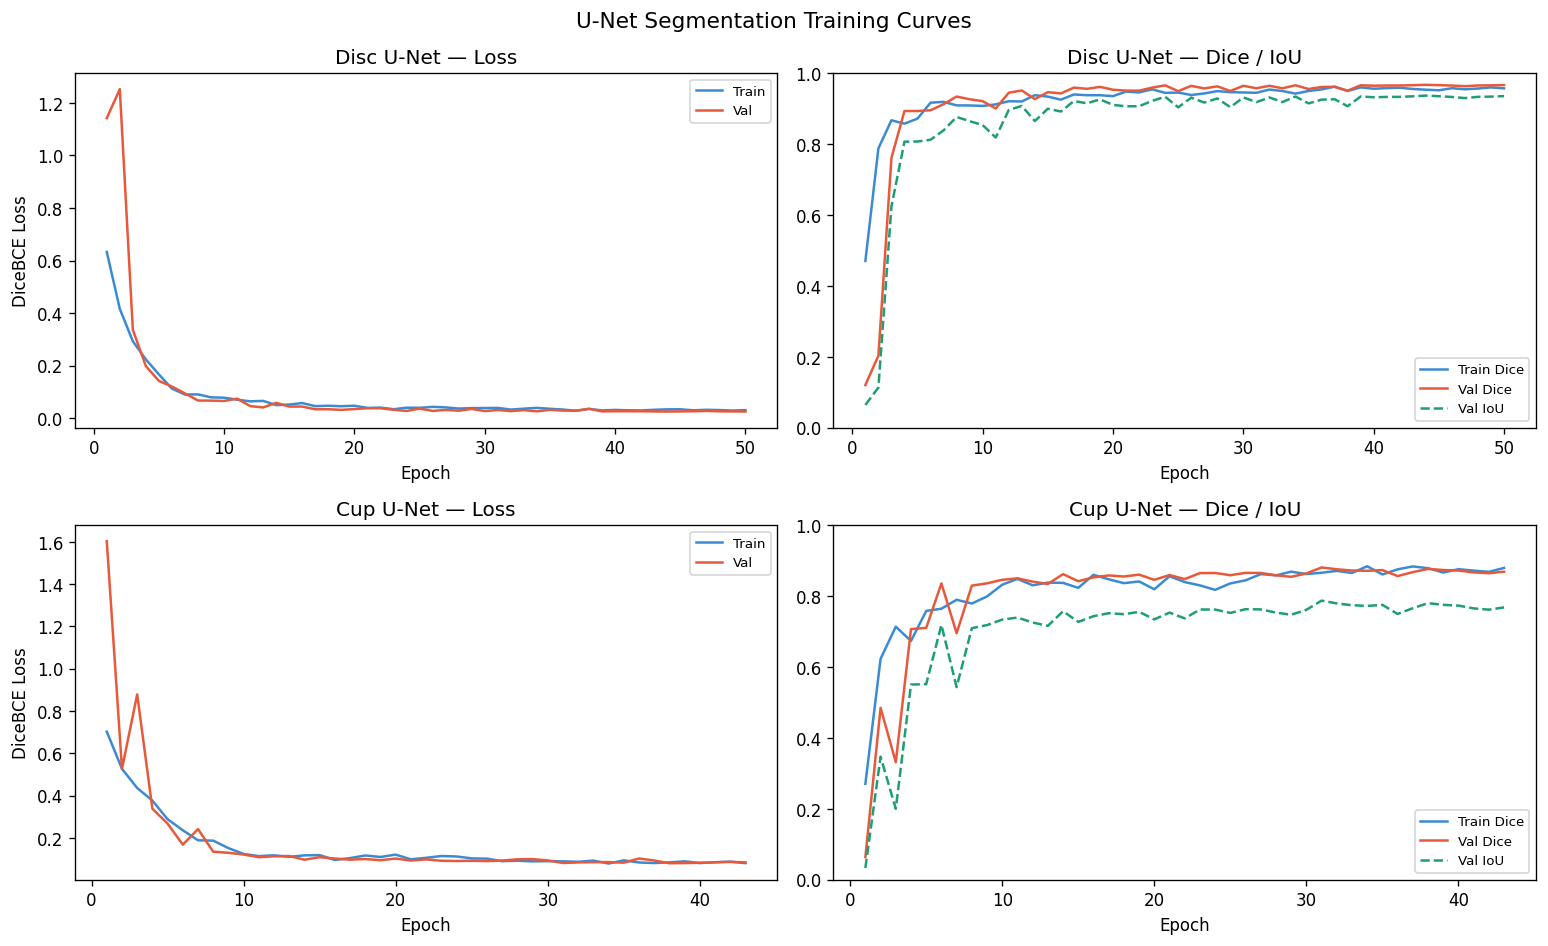

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for row, (history, title) in enumerate([
    (disc_history, 'Disc U-Net'),
    (cup_history,  'Cup U-Net'),
]):
    ep = range(1, len(history['train_loss']) + 1)

    axes[row][0].plot(ep, history['train_loss'], '#3B8BD4', label='Train')
    axes[row][0].plot(ep, history['val_loss'],   '#E8593C', label='Val')
    axes[row][0].set_title(f'{title} — Loss'); axes[row][0].legend(fontsize=8)
    axes[row][0].set_xlabel('Epoch'); axes[row][0].set_ylabel('DiceBCE Loss')

    axes[row][1].plot(ep, history['train_dice'], '#3B8BD4', label='Train Dice')
    axes[row][1].plot(ep, history['val_dice'],   '#E8593C', label='Val Dice')
    axes[row][1].plot(ep, history['val_iou'],    '#1D9E75', label='Val IoU', linestyle='--')
    axes[row][1].set_title(f'{title} — Dice / IoU'); axes[row][1].legend(fontsize=8)
    axes[row][1].set_xlabel('Epoch'); axes[row][1].set_ylim([0, 1])

plt.suptitle('U-Net Segmentation Training Curves', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'unet_training_curves.png', bbox_inches='tight')
plt.show()

## 7.5 Load best checkpoints and evaluate on DRISHTI val set

In [7]:
disc_model = disc_trainer.load_best()
cup_model  = cup_trainer.load_best()

# Evaluate Dice + IoU on the full DRISHTI set
from models.seg_trainer import dice_coefficient, iou_score

seg_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=NORMALIZE_MEAN, std=NORMALIZE_STD),
])

def eval_segmentation(model, df, mask_col):
    dice_scores, iou_scores = [], []
    model.eval()
    for _, row in df.iterrows():
        img_bgr = cv2.imread(str(row['image_path']))
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_res = cv2.resize(img_rgb, (SEG_IMAGE_SIZE[1], SEG_IMAGE_SIZE[0]))

        mask_raw = cv2.imread(str(row[mask_col]), cv2.IMREAD_GRAYSCALE)
        mask_res = cv2.resize(mask_raw, (SEG_IMAGE_SIZE[1], SEG_IMAGE_SIZE[0]))
        mask_bin = torch.tensor((mask_res > 127).astype(np.float32)).unsqueeze(0).unsqueeze(0)

        from PIL import Image
        tensor = seg_transform(Image.fromarray(img_res)).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            logits = model(tensor).cpu()

        dice_scores.append(dice_coefficient(logits, mask_bin))
        iou_scores.append(iou_score(logits, mask_bin))

    return np.mean(dice_scores), np.mean(iou_scores)

disc_dice, disc_iou = eval_segmentation(disc_model, valid_df, 'od_mask_path')
cup_dice,  cup_iou  = eval_segmentation(cup_model,  valid_df, 'cup_mask_path')

print(f'Disc segmentation  →  Dice: {disc_dice:.4f}   IoU: {disc_iou:.4f}')
print(f'Cup  segmentation  →  Dice: {cup_dice:.4f}    IoU: {cup_iou:.4f}')

Loaded disc_unet: epoch 44, Dice 0.9667, IoU 0.9363
Loaded cup_unet: epoch 31, Dice 0.8803, IoU 0.7868
Disc segmentation  →  Dice: 0.9677   IoU: 0.9378
Cup  segmentation  →  Dice: 0.8794    IoU: 0.7931


## 7.6 Segmentation visualisation on DRISHTI samples

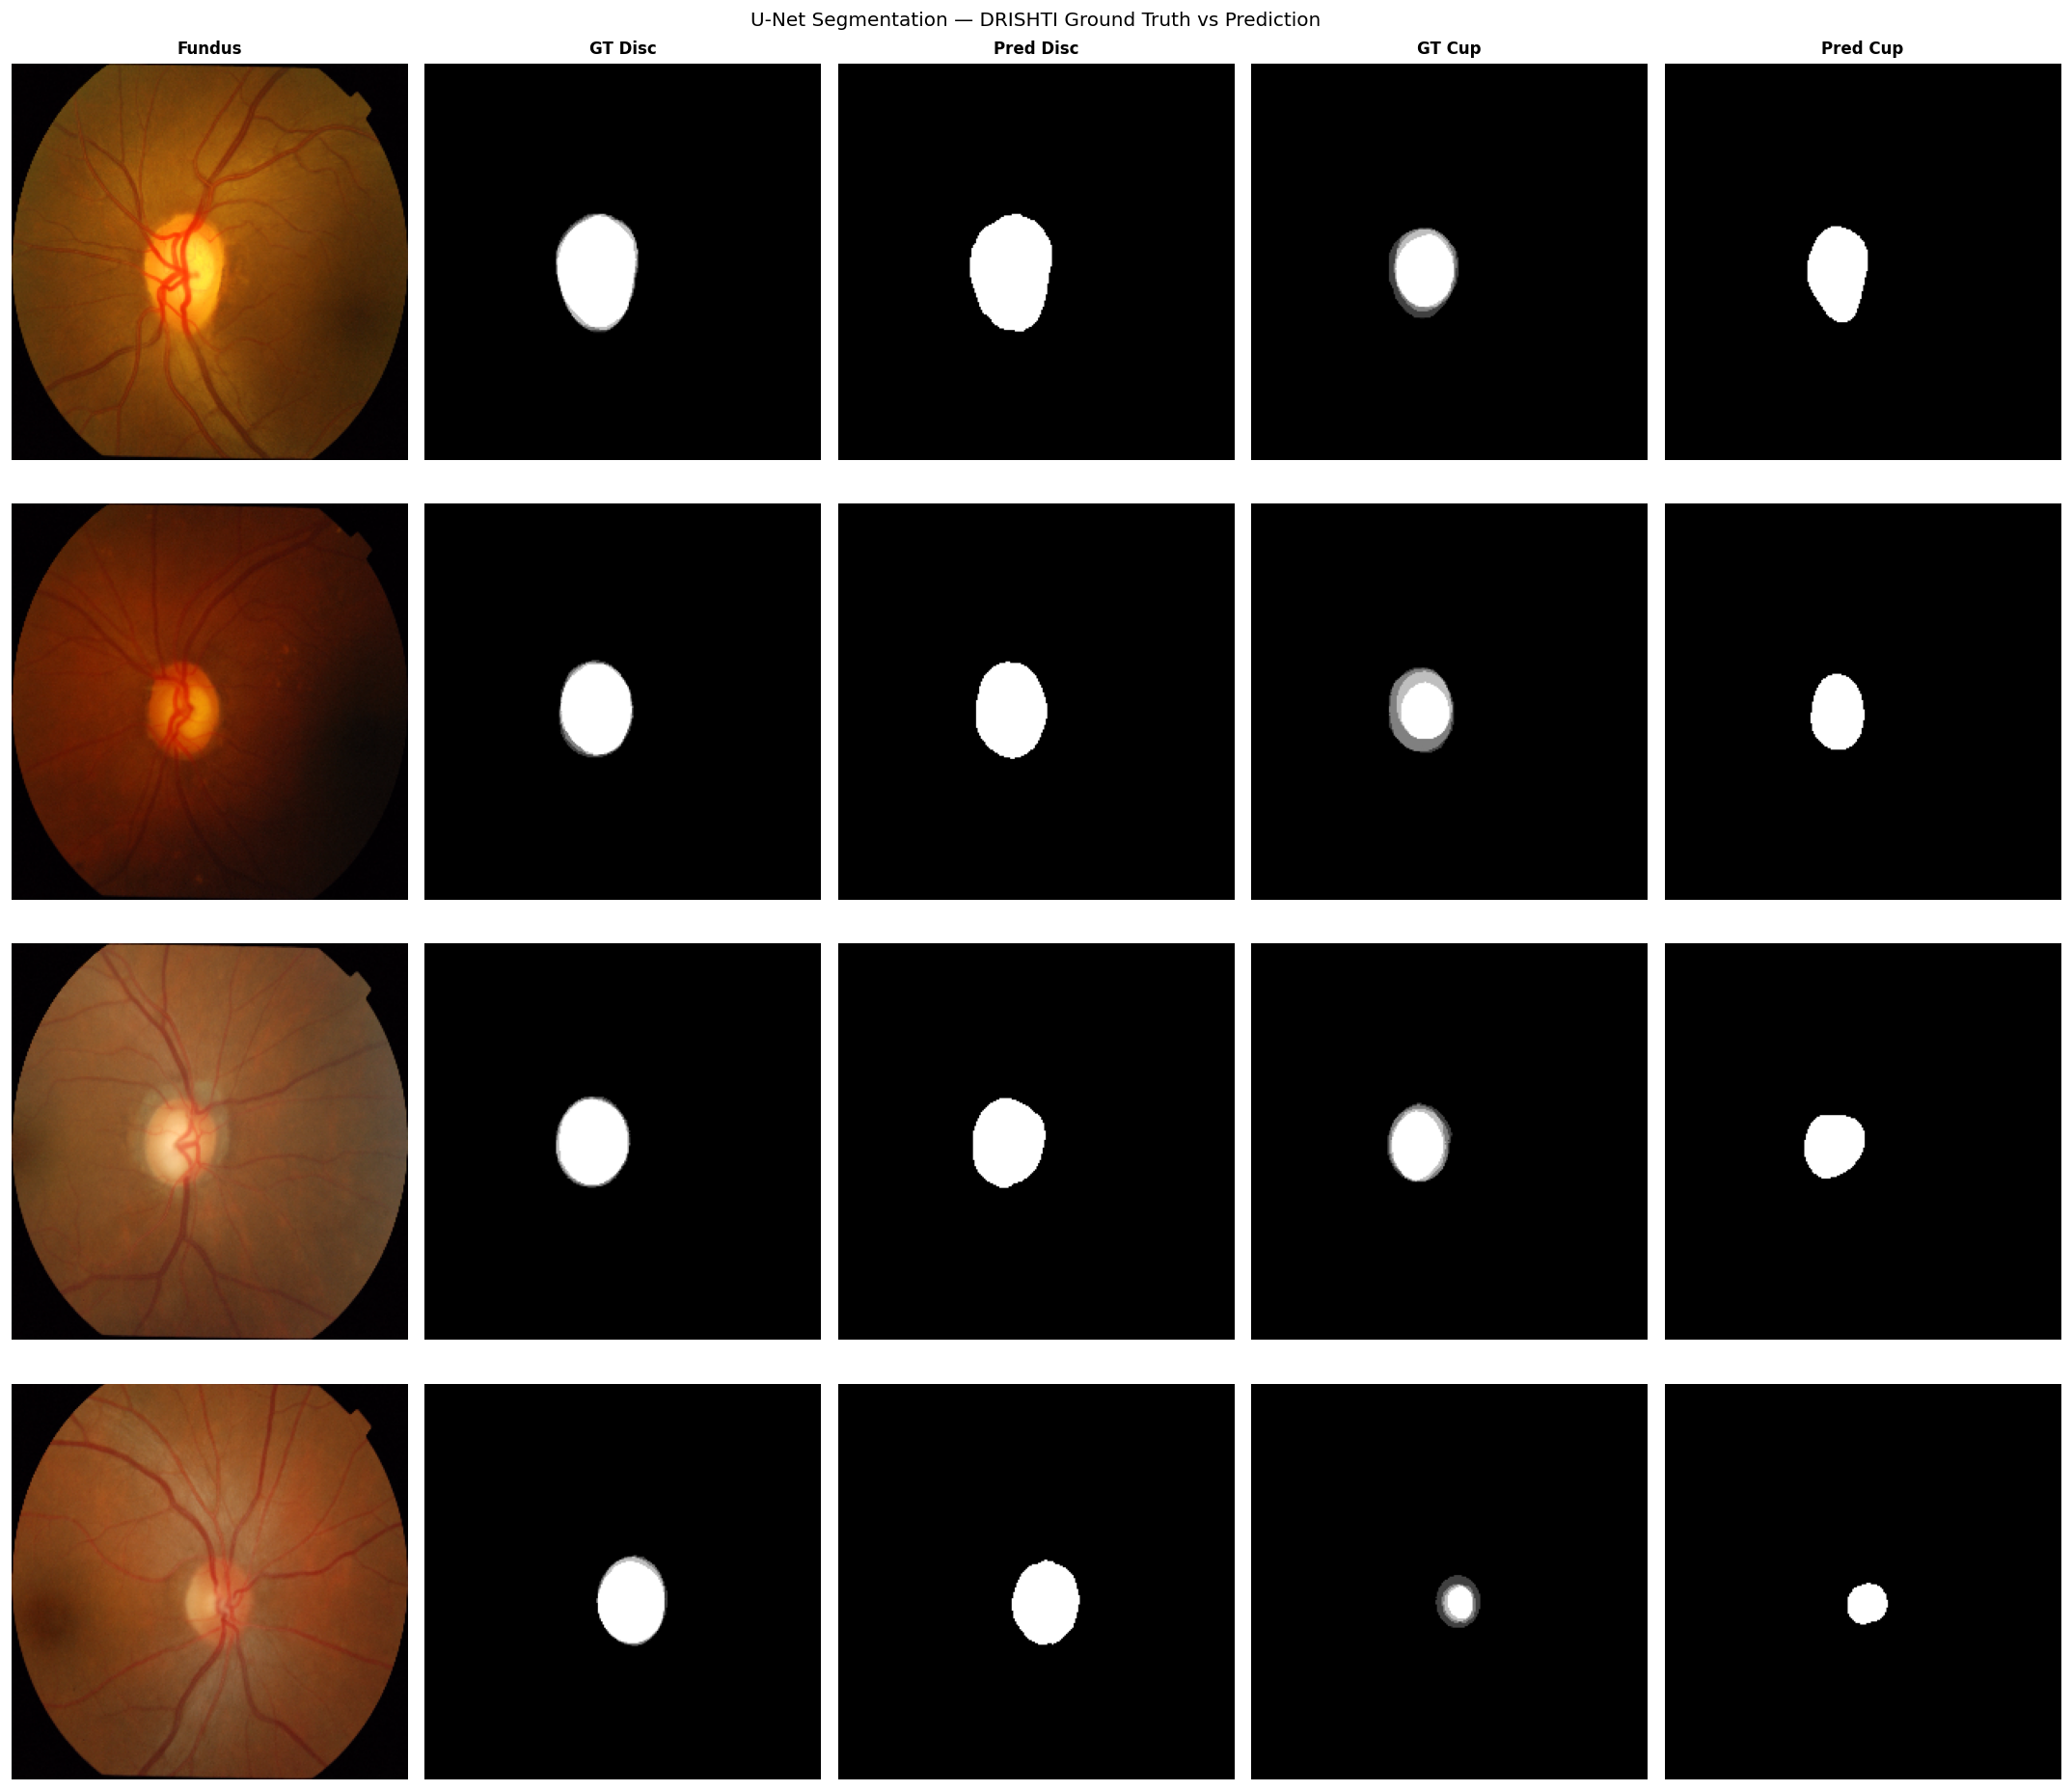

In [8]:
n_show  = min(4, len(valid_df))
samples = valid_df.sample(n_show, random_state=SEED)

fig, axes = plt.subplots(n_show, 5, figsize=(18, 4 * n_show))
if n_show == 1:
    axes = axes.reshape(1, -1)

col_headers = ['Fundus', 'GT Disc', 'Pred Disc', 'GT Cup', 'Pred Cup']
for ax, h in zip(axes[0], col_headers):
    ax.set_title(h, fontsize=10, fontweight='bold')

from PIL import Image as PILImage

for row_idx, (_, row) in enumerate(samples.iterrows()):
    img_bgr = cv2.imread(str(row['image_path']))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_res = cv2.resize(img_rgb, (SEG_IMAGE_SIZE[1], SEG_IMAGE_SIZE[0]))
    tensor  = seg_transform(PILImage.fromarray(img_res)).unsqueeze(0).to(DEVICE)

    gt_disc = cv2.resize(cv2.imread(str(row['od_mask_path']),  cv2.IMREAD_GRAYSCALE),
                         (SEG_IMAGE_SIZE[1], SEG_IMAGE_SIZE[0]))
    gt_cup  = cv2.resize(cv2.imread(str(row['cup_mask_path']), cv2.IMREAD_GRAYSCALE),
                         (SEG_IMAGE_SIZE[1], SEG_IMAGE_SIZE[0]))

    pred_disc = predict_mask(disc_model, tensor)
    pred_cup  = predict_mask(cup_model,  tensor)

    # Compute CDR for this sample
    cdr_gt   = row['cdr_mean']
    cdr_pred = compute_cdr_from_masks(pred_disc, pred_cup)

    for ax, im, cmap in zip(
        axes[row_idx],
        [img_res, gt_disc, pred_disc, gt_cup, pred_cup],
        [None, 'gray', 'gray', 'gray', 'gray']
    ):
        ax.imshow(im, cmap=cmap)
        ax.axis('off')

    axes[row_idx][0].set_ylabel(
        f'CDR gt={cdr_gt:.3f}\npred={cdr_pred:.3f}',
        fontsize=8, rotation=0, ha='right', va='center', labelpad=90
    )

plt.suptitle('U-Net Segmentation — DRISHTI Ground Truth vs Prediction', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'unet_segmentation_results.png', bbox_inches='tight')
plt.show()

## 7.7 Compute U-Net CDR for all classification datasets

In [9]:
df_all = load_all_datasets(include=['ACRIMA', 'RIMONE', 'AIROGS'], airogs_max_samples=2000)

disc_model.eval()
cup_model.eval()

cdr_unet_vals = []

for _, row in tqdm(df_all.iterrows(), total=len(df_all), desc='Computing CDR'):
    img_bgr = cv2.imread(str(row['image_path']))
    if img_bgr is None:
        cdr_unet_vals.append(0.5)
        continue

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_res = cv2.resize(img_rgb, (SEG_IMAGE_SIZE[1], SEG_IMAGE_SIZE[0]))
    tensor  = seg_transform(PILImage.fromarray(img_res)).unsqueeze(0).to(DEVICE)

    pred_disc = predict_mask(disc_model, tensor)
    pred_cup  = predict_mask(cup_model,  tensor)
    cdr       = compute_cdr_from_masks(pred_disc, pred_cup)
    cdr_unet_vals.append(cdr)

df_all['cdr_unet'] = cdr_unet_vals

print(f'\nCDR statistics per class:')
print(df_all.groupby('label')['cdr_unet'].describe().round(3))

[ACRIMA]  Total:   705  |  Glaucoma:  396  |  Normal:  309
[RIMONE]  Total:   485  |  Glaucoma:  172  |  Normal:  313
[AIROGS]  Total:  3540  |  Glaucoma: 1770  |  Normal: 1770

────────────────────────────────────────────────────
  COMBINED  Total   : 4730
            Glaucoma: 2338
            Normal  : 2392
────────────────────────────────────────────────────


Computing CDR: 100%|██████████| 4730/4730 [01:10<00:00, 66.80it/s]


CDR statistics per class:
        count   mean    std  min  25%    50%    75%  max
label                                                   
0      2392.0  0.652  0.182  0.0  0.5  0.690  0.790  1.0
1      2338.0  0.712  0.183  0.0  0.5  0.776  0.842  1.0


## 7.8 CDR comparison — proxy vs U-Net vs DRISHTI ground truth

CDR Method Comparison (vs DRISHTI ground truth):
Method              Pearson r  Spearman r      MAE
──────────────────────────────────────────────────
Proxy (Phase 3)         0.549           —    0.194
U-Net (Phase 7)         0.759       0.760    0.071


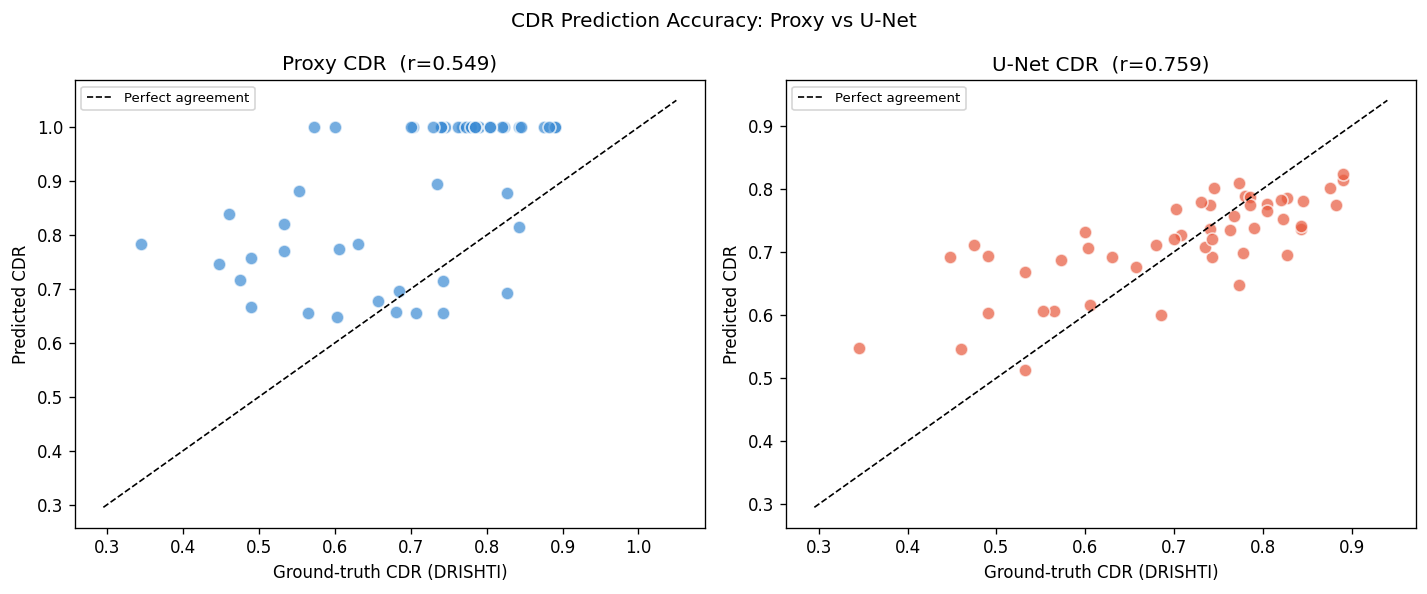

In [10]:
# Compute U-Net CDR on DRISHTI for comparison with ground truth
cdr_unet_drishti, cdr_gt_drishti = [], []

for _, row in valid_df.iterrows():
    img_bgr = cv2.imread(str(row['image_path']))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_res = cv2.resize(img_rgb, (SEG_IMAGE_SIZE[1], SEG_IMAGE_SIZE[0]))
    tensor  = seg_transform(PILImage.fromarray(img_res)).unsqueeze(0).to(DEVICE)

    pred_disc = predict_mask(disc_model, tensor)
    pred_cup  = predict_mask(cup_model,  tensor)
    cdr_unet_drishti.append(compute_cdr_from_masks(pred_disc, pred_cup))
    cdr_gt_drishti.append(row['cdr_mean'])

unet_arr = np.array(cdr_unet_drishti)
gt_arr   = np.array(cdr_gt_drishti)

unet_pearson,  _ = pearsonr(gt_arr, unet_arr)
unet_spearman, _ = spearmanr(gt_arr, unet_arr)
unet_mae         = np.mean(np.abs(unet_arr - gt_arr))

# Compare with proxy (from Phase 3)
from features.feature_extractor import extract_cdr_proxy
proxy_vals = []
for _, row in valid_df.iterrows():
    img_bgr = cv2.imread(str(row['image_path']))
    img_rgb_full = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_rgb = cv2.resize(img_rgb_full, (224, 224))
    proxy_vals.append(extract_cdr_proxy(img_rgb))

proxy_arr  = np.array(proxy_vals)
prx_pearson, _ = pearsonr(gt_arr, proxy_arr)
prx_mae        = np.mean(np.abs(proxy_arr - gt_arr))

print(f'CDR Method Comparison (vs DRISHTI ground truth):')
print(f'{"Method":<18} {"Pearson r":>10} {"Spearman r":>11} {"MAE":>8}')
print('─' * 50)
print(f'{"Proxy (Phase 3)":<18} {prx_pearson:>10.3f} {"—":>11} {prx_mae:>8.3f}')
print(f'{"U-Net (Phase 7)":<18} {unet_pearson:>10.3f} {unet_spearman:>11.3f} {unet_mae:>8.3f}')

# Scatter plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, pred, label, colour in [
    (axes[0], proxy_arr, f'Proxy CDR  (r={prx_pearson:.3f})',  '#3B8BD4'),
    (axes[1], unet_arr,  f'U-Net CDR  (r={unet_pearson:.3f})', '#E8593C'),
]:
    ax.scatter(gt_arr, pred, alpha=0.7, color=colour, edgecolors='white', s=60)
    lim = [min(gt_arr.min(), pred.min()) - 0.05, max(gt_arr.max(), pred.max()) + 0.05]
    ax.plot(lim, lim, 'k--', linewidth=1, label='Perfect agreement')
    ax.set_xlabel('Ground-truth CDR (DRISHTI)')
    ax.set_ylabel('Predicted CDR')
    ax.set_title(label)
    ax.legend(fontsize=8)

plt.suptitle('CDR Prediction Accuracy: Proxy vs U-Net', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cdr_proxy_vs_unet.png', bbox_inches='tight')
plt.show()

## 7.9 CDR distribution — Normal vs Glaucoma (U-Net)

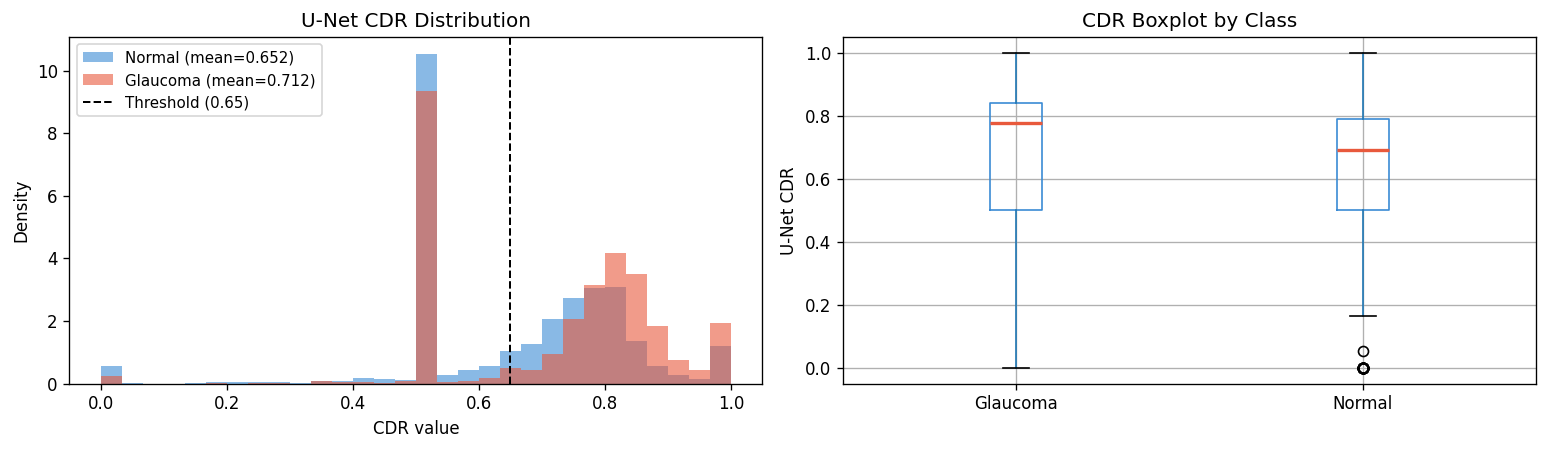

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, cdr_col, title in [
    (axes[0], 'cdr_unet', 'U-Net CDR'),
]:
    for label, name, colour in [(0,'Normal','#3B8BD4'), (1,'Glaucoma','#E8593C')]:
        vals = df_all[df_all['label']==label][cdr_col]
        ax.hist(vals, bins=30, alpha=0.6, color=colour,
                label=f'{name} (mean={vals.mean():.3f})', density=True)
    ax.axvline(CDR_GLAUCOMA_THRESHOLD, color='black', linestyle='--',
               linewidth=1.2, label=f'Threshold ({CDR_GLAUCOMA_THRESHOLD})')
    ax.set_xlabel('CDR value'); ax.set_ylabel('Density')
    ax.set_title(f'{title} Distribution')
    ax.legend(fontsize=9)

# Side-by-side CDR boxplot
df_plot = df_all[['label','cdr_unet']].copy()
df_plot['label_name'] = df_plot['label'].map({0:'Normal', 1:'Glaucoma'})
df_plot.boxplot(column='cdr_unet', by='label_name', ax=axes[1],
                boxprops=dict(color='#3B8BD4'),
                medianprops=dict(color='#E8593C', linewidth=2))
axes[1].set_title('CDR Boxplot by Class')
axes[1].set_xlabel(''); axes[1].set_ylabel('U-Net CDR')
plt.suptitle('')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'unet_cdr_distribution.png', bbox_inches='tight')
plt.show()

## 7.10 Save enriched dataset with U-Net CDR

In [12]:
save_path = RESULTS_DIR / 'dataset_with_unet_cdr.csv'
df_all[['image_path','label','dataset','split','cdr_unet']].to_csv(save_path, index=False)
print(f'Saved → {save_path}')

# Segmentation metrics summary for paper
seg_results = pd.DataFrame([{
    'target': 'Optic Disc',  'dice': disc_dice,
    'iou': disc_iou,
}, {
    'target': 'Optic Cup',   'dice': cup_dice,
    'iou': cup_iou,
}])
seg_results.to_csv(RESULTS_DIR / 'segmentation_metrics.csv', index=False)

print('\nSegmentation results summary:')
print(seg_results.round(4).to_string(index=False))

Saved → D:\Machine Learning\glaucoma detection project\outputs\results\dataset_with_unet_cdr.csv

Segmentation results summary:
    target   dice    iou
Optic Disc 0.9677 0.9378
 Optic Cup 0.8794 0.7931


---
## ✅ Phase 7 complete

Verify before moving on:
- Disc Dice > 0.80, Cup Dice > 0.70 (acceptable for 50-image dataset)
- U-Net CDR Pearson r > proxy CDR Pearson r (improvement over Phase 3)
- `dataset_with_unet_cdr.csv` saved — used in final evaluation
- `unet_segmentation_results.png` saved — paper figure

**If Dice is below target:**
- Try `epochs=80` with `patience=20` for more training time
- The 50-image DRISHTI dataset is the main constraint — results will vary

**Next → `07_final_evaluation.ipynb`**  
Final comparison of all models + cross-dataset analysis + complete paper results table.